# 2단계 · vectorbt 핵심 개념

이 노트북에서는 vectorbt의 핵심 작동 방식을 단계별로 익힙니다.

## 학습 목표
1. `Portfolio.from_signals()` 의 구조 이해
2. 롱/숏 시그널을 `True/False` 배열로 표현하는 방법
3. 수수료(fees), 슬리피지(slippage) 설정
4. 기본 수익률 계산 및 Buy & Hold 비교

---
## vectorbt 란?

vectorbt는 **numpy 배열 연산** 기반의 고성능 백테스팅 라이브러리입니다.  
기존 이벤트 드리븐 방식(예: Backtrader)과 달리, 전체 시계열을 한 번에 벡터 연산하므로  
수천 개의 파라미터 조합도 빠르게 테스트할 수 있습니다.

```
일반적인 백테스터:  for each day → check signal → execute order  (느림)
vectorbt:          signal_array[전체기간] → 한 번에 계산             (빠름)
```

## 0. 환경 준비

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import vectorbt as vbt
import yfinance as yf
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print(f'vectorbt 버전: {vbt.__version__}')
print(f'pandas 버전: {pd.__version__}')

vectorbt 버전: 0.26.2
pandas 버전: 1.5.3


## 1. 주가 데이터 로드

애플(AAPL) 주가를 받아서 vectorbt 백테스트의 기본 입력인 **종가(Close)** 시리즈를 준비합니다.

In [2]:
# Apple 주가 다운로드 (2018~2023)
ticker = 'AAPL'
df = yf.download(ticker, start='2018-01-01', end='2023-12-31',
                 auto_adjust=True, progress=False)

# MultiIndex 컬럼 정리
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

close = df['Close']
print(f'데이터 기간: {close.index[0].date()} ~ {close.index[-1].date()}')
print(f'총 거래일: {len(close)}일')
close.tail()

데이터 기간: 2018-01-02 ~ 2023-12-29
총 거래일: 1509일


Date
2023-12-22    191.609482
2023-12-26    191.065109
2023-12-27    191.164108
2023-12-28    191.589676
2023-12-29    190.550446
Name: Close, dtype: float64

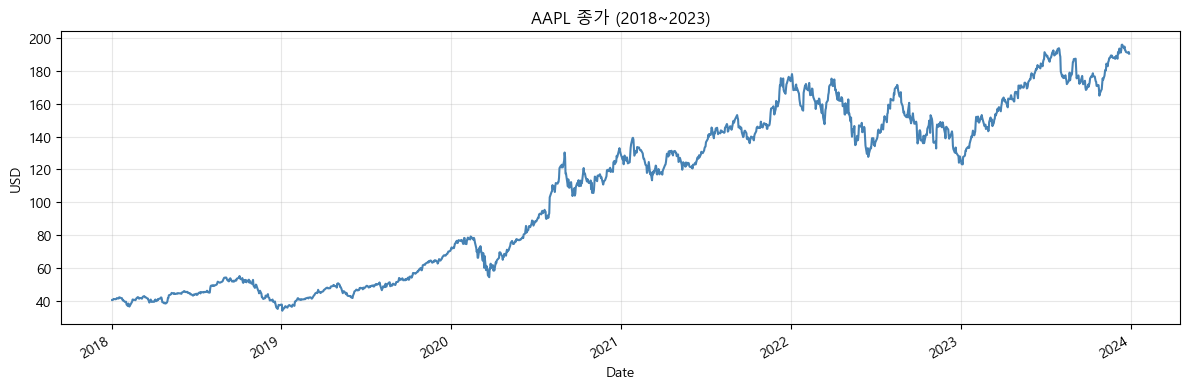

In [3]:
# 주가 차트로 확인
close.plot(figsize=(12, 4), title=f'{ticker} 종가 (2018~2023)', color='steelblue')
plt.ylabel('USD')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. 시그널(Signal) 이해하기

vectorbt의 핵심은 **True/False 배열**로 매수·매도 시점을 표현하는 것입니다.

```python
entries = True  ← 이 날 매수 진입
exits   = True  ← 이 날 매도 청산
```

같은 날 entries와 exits가 모두 True이면 exits가 우선합니다.

In [4]:
# 예시 1: 전날보다 가격이 내렸으면 매수, 올랐으면 매도
entries_ex1 = close < close.shift(1)   # 하락 → 매수
exits_ex1   = close > close.shift(1)   # 상승 → 매도

print('=== 시그널 미리보기 (처음 10일) ===')
preview = pd.DataFrame({
    'Close': close,
    'Entry(매수)': entries_ex1,
    'Exit(매도)': exits_ex1
}).head(10)
print(preview.to_string())

=== 시그널 미리보기 (처음 10일) ===
                Close  Entry(매수)  Exit(매도)
Date                                      
2018-01-02  40.304169      False     False
2018-01-03  40.297157       True     False
2018-01-04  40.484329      False      True
2018-01-05  40.945263      False      True
2018-01-08  40.793179       True     False
2018-01-09  40.788494       True     False
2018-01-10  40.779144       True     False
2018-01-11  41.010769      False      True
2018-01-12  41.434258      False      True
2018-01-16  41.223682       True     False


In [5]:
# 전체 기간에서 매수/매도 시그널이 몇 번 발생했는지 확인
print(f'매수 시그널 발생: {entries_ex1.sum()}번')
print(f'매도 시그널 발생: {exits_ex1.sum()}번')

매수 시그널 발생: 701번
매도 시그널 발생: 804번


## 3. Portfolio.from_signals() 기본 사용법

```python
pf = vbt.Portfolio.from_signals(
    close,      # 가격 데이터 (종가)
    entries,    # 매수 시그널 (True/False)
    exits,      # 매도 시그널 (True/False)
    fees=0.001, # 수수료 0.1%
)
```

### 주요 파라미터 설명
| 파라미터 | 설명 | 기본값 |
|---------|------|-------|
| `fees` | 거래 수수료 (비율) | 0.0 |
| `slippage` | 슬리피지 (체결 가격 불리하게 조정) | 0.0 |
| `init_cash` | 초기 투자금 | 100,000 |
| `freq` | 데이터 주기 ('D'=일봉, 'W'=주봉) | None |

In [6]:
# 수수료 없이 백테스트
pf_no_fee = vbt.Portfolio.from_signals(
    close, entries_ex1, exits_ex1, freq='D'
)

# 수수료 0.1% 적용
pf_with_fee = vbt.Portfolio.from_signals(
    close, entries_ex1, exits_ex1,
    fees=0.001,      # 0.1% 수수료
    slippage=0.001,  # 0.1% 슬리피지
    freq='D'
)

print(f'수수료 없음  → 총 수익률: {pf_no_fee.total_return():.2%}')
print(f'수수료 0.1% → 총 수익률: {pf_with_fee.total_return():.2%}')
print()
print('▶ 수수료가 수익률에 얼마나 영향을 주는지 확인!')

수수료 없음  → 총 수익률: 239.72%
수수료 0.1% → 총 수익률: -26.73%

▶ 수수료가 수익률에 얼마나 영향을 주는지 확인!


## 4. 주요 성과 지표 확인

`pf.total_return()`, `pf.sharpe_ratio()`, `pf.max_drawdown()` 등  
자주 쓰는 지표를 확인해봅니다.

In [7]:
pf = pf_with_fee  # 수수료 적용 버전 사용

print('=== 핵심 성과 지표 ===')
print(f'총 수익률   (Total Return)    : {pf.total_return():.2%}')
print(f'연평균수익률(CAGR)             : {pf.annualized_return():.2%}')
print(f'샤프 비율   (Sharpe Ratio)    : {pf.sharpe_ratio():.2f}')
print(f'최대 낙폭   (Max Drawdown)    : {pf.max_drawdown():.2%}')
print(f'총 거래 횟수                  : {pf.trades.count()}')

=== 핵심 성과 지표 ===
총 수익률   (Total Return)    : -26.73%
연평균수익률(CAGR)             : -7.25%
샤프 비율   (Sharpe Ratio)    : -0.14
최대 낙폭   (Max Drawdown)    : -42.64%
총 거래 횟수                  : 384


In [8]:
# pf.stats() 로 전체 통계 한 번에 확인
pf.stats()

Start                               2018-01-02 00:00:00
End                                 2023-12-29 00:00:00
Period                               1509 days 00:00:00
Start Value                                       100.0
End Value                                     73.268618
Total Return [%]                             -26.731382
Benchmark Return [%]                         372.780984
Max Gross Exposure [%]                            100.0
Total Fees Paid                               67.760105
Max Drawdown [%]                              42.637532
Max Drawdown Duration                 745 days 00:00:00
Total Trades                                        384
Total Closed Trades                                 383
Total Open Trades                                     1
Open Trade PnL                                -0.146611
Win Rate [%]                                  56.396867
Best Trade [%]                                 8.818845
Worst Trade [%]                              -10

## 5. Buy & Hold 와 비교하기

전략의 성과를 평가할 때는 항상 **벤치마크(Buy & Hold)** 와 비교해야 합니다.  
아무 전략 없이 처음부터 끝까지 보유만 했을 때의 수익률이 기준선입니다.

In [13]:
# Buy & Hold 포트폴리오 (첫날 매수, 마지막 날 매도)
bh_entries = pd.Series(False, index=close.index)
bh_exits   = pd.Series(False, index=close.index)
bh_entries.iloc[0] = True   # 첫날 매수
bh_exits.iloc[-1]  = True   # 마지막 날 매도

pf_bh = vbt.Portfolio.from_signals(
    close, bh_entries, bh_exits, 
    fees=0.001,      # 0.1% 수수료
    slippage=0.001,  # 0.1% 슬리피지 
    freq='D'
)

print('=== 전략 vs Buy & Hold ===')
print(f'우리 전략   총 수익률: {pf.total_return():.2%}')
print(f'Buy & Hold  총 수익률: {pf_bh.total_return():.2%}')
print()
print(f'우리 전략   샤프비율: {pf.sharpe_ratio():.2f}')
print(f'Buy & Hold  샤프비율: {pf_bh.sharpe_ratio():.2f}')
print()
print(f'우리 전략   최대낙폭: {pf.max_drawdown():.2%}')
print(f'Buy & Hold  최대낙폭: {pf_bh.max_drawdown():.2%}')

=== 전략 vs Buy & Hold ===
우리 전략   총 수익률: -26.73%
Buy & Hold  총 수익률: 370.89%

우리 전략   샤프비율: -0.14
Buy & Hold  샤프비율: 1.17

우리 전략   최대낙폭: -42.64%
Buy & Hold  최대낙폭: -38.52%


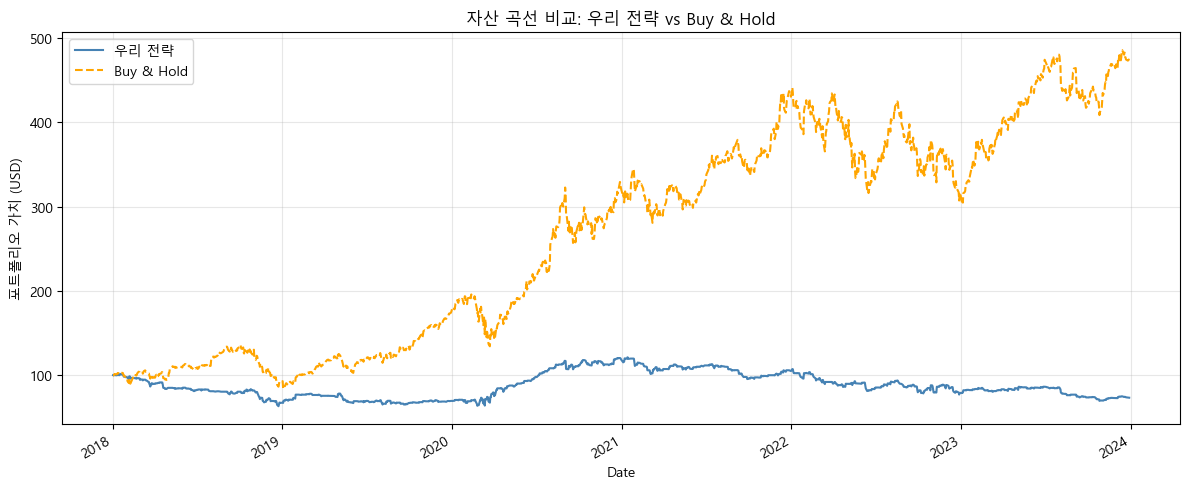

In [14]:
# 자산 곡선(누적 수익) 비교 차트
fig, ax = plt.subplots(figsize=(12, 5))

pf.value().plot(ax=ax, label='우리 전략', color='steelblue')
pf_bh.value().plot(ax=ax, label='Buy & Hold', color='orange', linestyle='--')

ax.set_title('자산 곡선 비교: 우리 전략 vs Buy & Hold')
ax.set_ylabel('포트폴리오 가치 (USD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 수수료·슬리피지의 영향 분석

거래 빈도가 높은 전략일수록 수수료가 수익률에 큰 영향을 줍니다.  
수수료를 0% ~ 0.5% 까지 변화시키며 영향을 확인해봅니다.

수수료 0.0% → 총 수익률: 239.72%
수수료 0.1% → 총 수익률: 57.77%
수수료 0.2% → 총 수익률: -26.73%
수수료 0.5% → 총 수익률: -92.66%


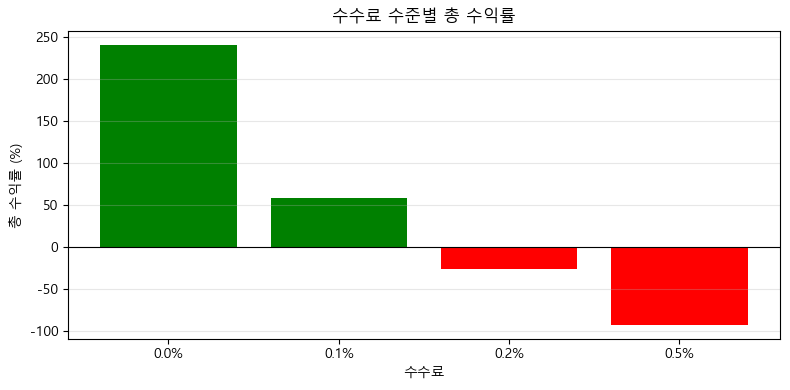

In [15]:
fee_levels = [0.0, 0.001, 0.002, 0.005]
returns_by_fee = []

for fee in fee_levels:
    pf_temp = vbt.Portfolio.from_signals(
        close, entries_ex1, exits_ex1, fees=fee, freq='D'
    )
    returns_by_fee.append(pf_temp.total_return())
    print(f'수수료 {fee:.1%} → 총 수익률: {pf_temp.total_return():.2%}')

# 차트로 시각화
plt.figure(figsize=(8, 4))
plt.bar([f'{f:.1%}' for f in fee_levels], [r * 100 for r in returns_by_fee],
        color=['green' if r > 0 else 'red' for r in returns_by_fee])
plt.title('수수료 수준별 총 수익률')
plt.xlabel('수수료')
plt.ylabel('총 수익률 (%)')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 7. 포지션 사이징 - 투자 비율 조정

기본값은 매수 시 **가용 현금 전액**을 투자합니다.  
`size` 파라미터로 투자 비율을 조정할 수 있습니다.

In [16]:
import vectorbt as vbt

# 매수 시 50%만 투자
pf_half = vbt.Portfolio.from_signals(
    close, entries_ex1, exits_ex1,
    fees=0.001,
    size=0.5,                # 가용 현금의 50%만 투자
    size_type='percent',     # 'percent' = 가용 현금 비율 (from_signals 지원)
    freq='D'
)

print('=== 투자 비율별 비교 ===')
print(f'100% 투자 → 총 수익률: {pf.total_return():.2%}, 최대낙폭: {pf.max_drawdown():.2%}')
print(f' 50% 투자 → 총 수익률: {pf_half.total_return():.2%}, 최대낙폭: {pf_half.max_drawdown():.2%}')

=== 투자 비율별 비교 ===
100% 투자 → 총 수익률: -26.73%, 최대낙폭: -42.64%
 50% 투자 → 총 수익률: 29.09%, 최대낙폭: -16.17%


## 8. 이번 단계 정리

| 개념 | 핵심 내용 |
|-----|----------|
| **시그널** | True/False 배열로 매수(entries)·매도(exits) 표현 |
| **Portfolio.from_signals()** | 가격 + 시그널 → 포트폴리오 객체 생성 |
| **수수료/슬리피지** | `fees`, `slippage` 파라미터로 현실적인 비용 반영 |
| **성과 지표** | `total_return()`, `sharpe_ratio()`, `max_drawdown()` |
| **벤치마크** | Buy & Hold 와 비교해서 전략 우위 검증 |

### 다음 단계
3단계에서는 이동평균, RSI, MACD 등 **실제 기술 지표를 활용한 전략**을 구현합니다.